In [1]:
%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Users\Victor\AppData\Local\Programs\Python\Python312\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Victor\AppData\Local\Programs\Python\Python312\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen impor

In [2]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [3]:
import logging

import torch

from scripts import (
    generate_dataset,
    generate_pred_datasets,
    optuna_search,
    predictions,
    training,
)
from src.utils import configure_logger

logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

# Generate datasets

In [ ]:
backend = "pennylane"  # "pennylane" | "qiskit" | "cirq"
target = "SRE"
method = "fwht"
output_dir = "/outputs/data/identity/training_data"
n_bins = 50
families = "random"
n_seeds = 150

In [6]:
generate_dataset(
    backend=backend,
    target=target,
    method=method,
    use_dask=True,
    output_dir="/outputs/data/general_dataset",
    n_bins_option=n_bins,
    families=families,
    n_seeds_option=n_seeds,
    prediction_n_seeds_option=50,
    qubits_min=4,
    qubits_max=30,
    qubits_step=2,
    layers_min=2,
    layers_max=100,
    layers_step=2,
    target_qubits = "4,6,8,10",
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="32GiB",
)

2026-05-12 14:46:53,530 - qqe.src.GNN.dataset_builder - INFO - Processing family: random
2026-05-12 14:46:53,939 - qqe.src.GNN.dataset_builder - INFO - Generated 124950 configs for random
2026-05-12 14:46:54,300 - qqe.src.parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-05-12 14:46:54,732 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-05-12 14:46:54,758 - distributed.scheduler - INFO - State start
2026-05-12 14:46:54,780 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:64473
2026-05-12 14:46:54,781 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-05-12 14:46:54,782 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-05-12 14:46:54,808 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 32GiB due to system memory limit of 31.19 GiB
2026-0

### Identity-like

In [4]:
from qqe.src.GNN.dataset_builder import SamplingConfig, RegimeDistribution

In [ ]:
backend = "pennylane"  # "pennylane" | "qiskit" | "cirq"
target = "SRE"
method = "fwht"
output_dir = "/outputs/data/identity/training_data"
n_bins = 50
families = "random"
n_seeds = 175

sampling_config = SamplingConfig(
    clifford=RegimeDistribution(
        regimes=["zero", "low", "medium", "high"],
        probabilities=[0.15, 0.15, 0.25, 0.45],
    ),
    random=RegimeDistribution(
        regimes=["identity_like", "clifford_like", "small_angles", "generic"],
        probabilities=[1.0, 0.0, 0.0, 0.0],
    ),
    quansistor=RegimeDistribution(
        regimes=["identity_like", "weak", "moderate", "structured_equal_ab", "structured_opposite_ab", "generic_uniform"],
        probabilities=[0.10, 0.20, 0.25, 0.15, 0.15, 0.15],
    ),
    haar=RegimeDistribution(
        regimes=["none", "sparse_weak", "dense_weak", "sparse_full", "medium", "full"],
        probabilities=[0.10, 0.20, 0.20, 0.15, 0.20, 0.15],
    ),
)

In [14]:
output_path = Path(output_dir)
print(f"Output path: {output_path}")

Output path: \outputs\data\training_data\identity


In [ ]:
generate_dataset(
    backend=backend,
    target=target,
    method=method,
    use_dask=True,
    output_dir=output_dir,
    n_bins_option=n_bins,
    families=families,
    n_seeds_option=n_seeds,
    qubits_min=4,
    qubits_max=10,
    qubits_step=2,
    layers_min=2,
    layers_max=100,
    layers_step=2,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
)

2026-05-12 13:44:44,693 - qqe.src.GNN.dataset_builder - INFO - Processing family: random
2026-05-12 13:44:44,844 - qqe.src.GNN.dataset_builder - INFO - Generated 10200 configs for random
2026-05-12 13:44:44,890 - qqe.src.parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 60093 instead
  warnings.warn(
2026-05-12 13:44:46,877 - distributed.scheduler - INFO - State start
2026-05-12 13:44:47,695 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:53581
2026-05-12 13:44:47,704 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:60093/status
2026-05-12 13:44:47,782 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-05-12 13:44:48,313 - distributed.nanny - INFO -         S

KeyboardInterrupt: 

2026-05-12 13:45:30,140 - distributed.scheduler - INFO - Register worker addr: tcp://127.0.0.1:53652 name: 0
2026-05-12 13:45:30,240 - distributed.scheduler - INFO - Starting worker compute stream, tcp://127.0.0.1:53652
2026-05-12 13:45:30,246 - distributed.core - INFO - Starting established connection to tcp://127.0.0.1:53657
2026-05-12 13:45:30,295 - distributed.scheduler - INFO - Register worker addr: tcp://127.0.0.1:53658 name: 1
2026-05-12 13:45:30,297 - distributed.scheduler - INFO - Starting worker compute stream, tcp://127.0.0.1:53658
2026-05-12 13:45:30,298 - distributed.core - INFO - Starting established connection to tcp://127.0.0.1:53660
2026-05-12 13:45:30,445 - distributed.scheduler - INFO - Register worker addr: tcp://127.0.0.1:53648 name: 3
2026-05-12 13:45:30,446 - distributed.scheduler - INFO - Starting worker compute stream, tcp://127.0.0.1:53648
2026-05-12 13:45:30,447 - distributed.core - INFO - Starting established connection to tcp://127.0.0.1:53653
2026-05-12 13

In [6]:
n_seeds = 50
output_dir = "/outputs/data/identity/prediction_data"

True

In [7]:
generate_pred_datasets(
    backend=backend,
    method="none",
    use_dask=True,
    output_dir=output_dir,
    n_bins_option=n_bins,
    families=families,
    sampling_config=sampling_config,
    n_seeds_option=n_seeds,
    qubits_min=12,
    qubits_max=30,
    qubits_step=2,
    layers_min=2,
    layers_max=100,
    layers_step=2,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
)

2026-05-12 13:59:07,209 - qqe.src.GNN.dataset_builder - INFO - Processing family: random
2026-05-12 13:59:07,252 - qqe.src.GNN.dataset_builder - INFO - Generated 25500 configs for random
2026-05-12 13:59:07,513 - qqe.src.parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-05-12 13:59:07,838 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-05-12 13:59:07,861 - distributed.scheduler - INFO - State start
2026-05-12 13:59:07,865 - distributed.diskutils - INFO - Found stale lock file and directory 'C:\\Users\\Victor\\AppData\\Local\\Temp\\dask-scratch-space\\scheduler-6cwpwal9', purging
2026-05-12 13:59:07,866 - distributed.diskutils - INFO - Found stale lock file and directory 'C:\\Users\\Victor\\AppData\\Local\\Temp\\dask-scratch-space\\scheduler-797hkhxf', purging
2026-05-12 13:59:07,868 - distributed.diskutils - INFO - Found stale loc

SystemExit: 

c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
backend = "pennylane"  # "pennylane" | "qiskit" | "cirq"
target = "SRE"
method = "fwht"
output_dir = "/outputs/data/generic/training_data"
n_bins = 50
families = "random"
n_seeds = 100

sampling_config = SamplingConfig(
    clifford=RegimeDistribution(
        regimes=["zero", "low", "medium", "high"],
        probabilities=[0.15, 0.15, 0.25, 0.45],
    ),
    random=RegimeDistribution(
        regimes=["identity_like", "clifford_like", "small_angles", "generic"],
        probabilities=[0.0, 0.0, 0.0, 1.0],
    ),
    quansistor=RegimeDistribution(
        regimes=["identity_like", "weak", "moderate", "structured_equal_ab", "structured_opposite_ab", "generic_uniform"],
        probabilities=[0.10, 0.20, 0.25, 0.15, 0.15, 0.15],
    ),
    haar=RegimeDistribution(
        regimes=["none", "sparse_weak", "dense_weak", "sparse_full", "medium", "full"],
        probabilities=[0.10, 0.20, 0.20, 0.15, 0.20, 0.15],
    ),
)

In [ ]:
generate_dataset(
    backend=backend,
    target=target,
    method=method,
    use_dask=True,
    output_dir=output_dir,
    n_bins_option=n_bins,
    families=families,
    sampling_config=sampling_config,
    n_seeds_option=n_seeds,
    qubits_min=4,
    qubits_max=10,
    qubits_step=2,
    layers_min=2,
    layers_max=100,
    layers_step=2,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
)

# Training

In [ ]:
model_type="gnn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/identity_dataset"

In [5]:
default_model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 2,
    "dropout_rate": 0.10,
}

default_train_hparams = {
    "weight_decay": 0.00025,
    "grad_clip": 0.04,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

2026-05-13 13:07:13,301 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-05-13 13:07:13,302 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-13 13:07:13,303 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-13 13:09:12,572 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-13 13:09:12,574 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-13 13:09:12,575 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-05-13 13:10:50,735 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-13 13:10:50,736 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-13 13:10:50,911 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


Using device: cuda
Epoch 1/30:  81%|████████  | 650/804 [01:00<00:14, 10.40it/s, loss=0.0001, graphs=20832]

2026-05-13 13:11:50,969 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 651/804 | loss 0.000092 | elapsed 60.1s | graphs 20832


2026-05-13 13:12:05,323 - qqe.src.GNN.training.train - INFO - Training complete (74.4s) | running validation...


2026-05-13 13:12:13,232 - qqe.src.GNN.training.train - INFO - Losses | train 0.000084 | val 0.000031 | lr 1.00e-04 | time train=74.4s val=7.9s total=82.3s
2026-05-13 13:12:13,235 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


...

2026-05-13 13:47:57,197 - qqe.src.GNN.training.train - INFO - Losses | train 0.000034 | val 0.000029 | lr 2.50e-05 | time train=78.6s val=8.0s total=86.6s
2026-05-13 13:47:57,197 - qqe.src.GNN.training.train - INFO - -------- EPOCH 026 --------


Epoch 26/30:  75%|███████▌  | 606/804 [01:00<00:22,  8.69it/s, loss=0.0000, graphs=19424]

2026-05-13 13:48:57,225 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 26 batch 607/804 | loss 0.000033 | elapsed 60.0s | graphs 19424


2026-05-13 13:49:16,138 - qqe.src.GNN.training.train - INFO - Training complete (78.9s) | running validation...


2026-05-13 13:49:24,555 - qqe.src.GNN.training.train - INFO - Losses | train 0.000034 | val 0.000030 | lr 2.50e-05 | time train=78.9s val=8.4s total=87.4s
2026-05-13 13:49:24,555 - qqe.src.GNN.training.train - INFO - Early stopping at epoch 026 | best val 0.000028 | patience exhausted (10/10)
2026-05-13 13:49:48,118 - qqe.src.GNN.training.runners - INFO - Training complete.


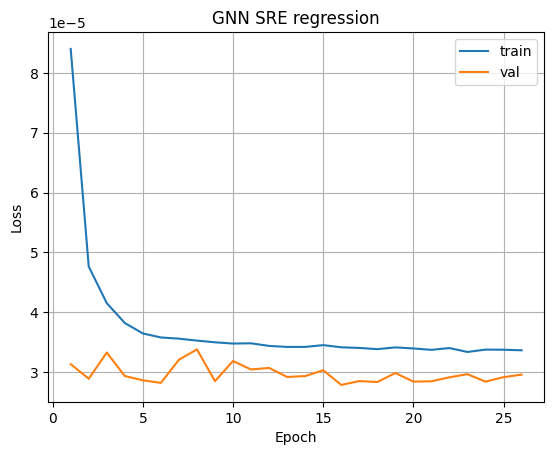

2026-05-13 13:49:48,295 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ..\outputs\models\gnn_huber_random.pt
2026-05-13 13:49:48,298 - scripts.train_model - INFO - Final test loss: 0.000029


In [6]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_type=model_type,
    model_hparams=default_model_hparams,
    train_hparams=default_train_hparams,
    training_data_dir=data_dir,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

In [7]:
predictions(
    model_path="../outputs/models/gnn_huber_random.pt",
    model_kind="gnn",
    training_scope="family",
    loss_type="huber",
    model_family="random",
    dataset_root=data_dir,
    dataset_family="random",
    batch_size=32,
    global_feature_variant="binned"
    ,
    node_feature_backend_variant=None,
    plot_n_layers=10,
    plot_n_qubits=18,
    split_by_family=True,
    show_progress=True,
)

2026-05-13 13:51:29,929 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/gnn_huber_random.pt
2026-05-13 13:52:01,788 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (gnn): 100%|██████████| 3905/3905 [11:30<00:00,  5.66batch/s]
2026-05-13 14:03:41,428 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/gnn_predictions_random.csv
2026-05-13 14:03:41,623 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/gnn_pred_layers_random.png
2026-05-13 14:03:41,837 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/gnn_pred_qubits_random.png


In [12]:
from qqe.src.experiments.plotting import view_correlation
import pandas as pd

In [10]:
df = pd.read_csv("../outputs/predictions/family/gnn_predictions_random.csv")

In [14]:
import ast

def to_scalar(x):
    # Already numeric
    if isinstance(x, (int, float)):
        return x

    # torch / numpy scalar
    if hasattr(x, "item"):
        return x.item()

    # Strings
    if isinstance(x, str):
        x = x.strip()

        # Handle tensor(...) by stripping wrapper FIRST
        if x.startswith("tensor(") and x.endswith(")"):
            x = x[len("tensor("):-1].strip()

        try:
            val = ast.literal_eval(x)
        except Exception:
            # fallback: plain float string
            return float(x)

        # If it's a list/tuple like [10]
        if isinstance(val, (list, tuple)):
            if len(val) == 1:
                return float(val[0])
            raise ValueError(f"Unexpected list length: {val}")

        return float(val)

    raise ValueError(f"Unsupported type: {type(x)}")

In [ ]:
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

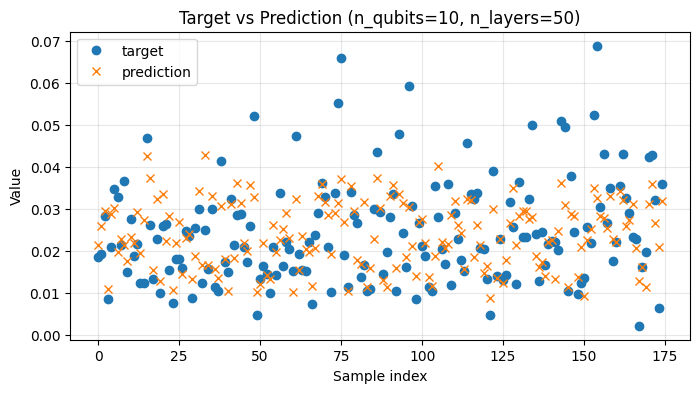

Pearson r = 0.7113


: 

In [ ]:
view_correlation(
    df,
    nq=10,
    nl=50,
    col_x="target",
    col_y="prediction",
)

In [7]:
model_type="nn"
epochs = 25
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/identity_dataset"

In [8]:
default_model_hparams = {
    "hidden_dim": 128,
    "dropout_rate": 0.0,
}

default_train_hparams = {
    "weight_decay": 1e-3,
    "grad_clip": 5.0,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

2026-05-13 14:47:47,670 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=nn | training_mode=per_family | family=random | loss_type=huber
2026-05-13 14:47:47,671 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-13 14:47:47,671 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-13 14:49:49,406 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-13 14:49:49,407 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-13 14:49:49,408 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=nn...
2026-05-13 14:50:22,359 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-13 14:50:22,359 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-13 14:50:22,506 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


Using device: cuda
                                                                                        

2026-05-13 14:51:11,306 - qqe.src.GNN.training.train - INFO - Training complete (48.8s) | running validation...


2026-05-13 14:51:16,241 - qqe.src.GNN.training.train - INFO - Losses | train 0.000052 | val 0.000029 | lr 1.00e-04 | time train=48.8s val=4.9s total=53.7s
2026-05-13 14:51:16,244 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


2026-05-13 14:52:04,314 - qqe.src.GNN.training.train - INFO - Training complete (48.1s) | running validation...


...

2026-05-13 15:00:14,262 - qqe.src.GNN.training.train - INFO - Losses | train 0.000036 | val 0.000031 | lr 5.00e-05 | time train=49.0s val=4.8s total=53.8s
2026-05-13 15:00:14,262 - qqe.src.GNN.training.train - INFO - -------- EPOCH 012 --------


2026-05-13 15:01:03,224 - qqe.src.GNN.training.train - INFO - Training complete (49.0s) | running validation...


2026-05-13 15:01:08,041 - qqe.src.GNN.training.train - INFO - Losses | train 0.000036 | val 0.000032 | lr 5.00e-05 | time train=49.0s val=4.8s total=53.8s
2026-05-13 15:01:08,042 - qqe.src.GNN.training.train - INFO - -------- EPOCH 013 --------


2026-05-13 15:01:57,110 - qqe.src.GNN.training.train - INFO - Training complete (49.1s) | running validation...


2026-05-13 15:02:02,174 - qqe.src.GNN.training.train - INFO - Losses | train 0.000036 | val 0.000032 | lr 5.00e-05 | time train=49.1s val=5.1s total=54.1s
2026-05-13 15:02:02,176 - qqe.src.GNN.training.train - INFO - Early stopping at epoch 013 | best val 0.000026 | patience exhausted (10/10)
2026-05-13 15:02:14,656 - qqe.src.GNN.training.runners - INFO - Training complete.


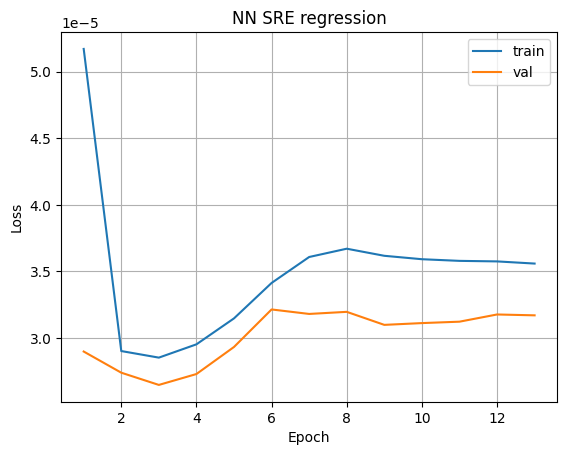

2026-05-13 15:02:14,812 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ..\outputs\models\nn_huber_random.pt
2026-05-13 15:02:14,815 - scripts.train_model - INFO - Final test loss: 0.000028


In [9]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_type=model_type,
    model_hparams=default_model_hparams,
    train_hparams=default_train_hparams,
    training_data_dir=data_dir,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

In [10]:
predictions(
    model_path="../outputs/models/nn_huber_random.pt",
    model_kind="nn",
    training_scope="family",
    loss_type="huber",
    model_family="random",
    dataset_root=data_dir,
    dataset_family="random",
    batch_size=32,
    global_feature_variant="binned"
    ,
    node_feature_backend_variant=None,
    plot_n_layers=10,
    plot_n_qubits=18,
    split_by_family=True,
    show_progress=True,
)

2026-05-13 15:14:19,939 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/nn_huber_random.pt
2026-05-13 15:14:46,152 - scripts.predictions - INFO - Found 124950 prediction files
Predicting (nn): 100%|██████████| 3905/3905 [02:28<00:00, 26.36batch/s]
2026-05-13 15:17:14,692 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/nn_predictions_random.csv
2026-05-13 15:17:14,822 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/nn_pred_layers_random.png
2026-05-13 15:17:14,947 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/nn_pred_qubits_random.png


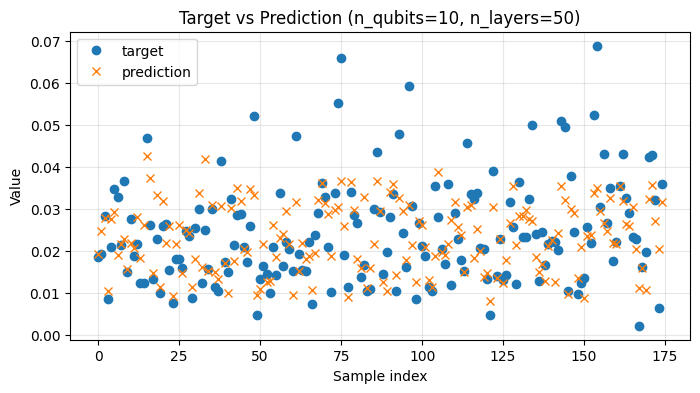

Pearson r = 0.7276


In [15]:
df = pd.read_csv("../outputs/predictions/family/nn_predictions_random.csv")

cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

view_correlation(
    df,
    nq=10,
    nl=50,
    col_x="target",
    col_y="prediction",
)